This is a simple notebook to explore Gradient Descent methods linear data with some (non-Gaussian) scatter.  
It accompanies Chapter 5 of the book (2 of 5).  
Copyright: Viviana Acquaviva (2023)  
Modified by Aaron Romanowsky.  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/) 
The implementation used for the Gradient Descent examples is adapted from [Aurelien Geron's code](https://github.com/ageron/handson-ml2/blob/master/LICENSE).

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import linear_model
import time

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [2]:
model = linear_model.LinearRegression()

In [3]:
np.random.seed(16) #set seed for reproducibility purposes
x = np.arange(100) 
X = x.reshape(-1,1)
y = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) #generate some data with scatter following Poisson distribution 
                                                       #with exp value = y from linear model, centered around 0

### We can use the data set with outliers from the previous notebook.

In [4]:
np.random.seed(12) #set 
out = np.random.choice(100,15) #select 15 outliers indexes
y_wo = np.copy(y)
np.random.seed(12) #set again
y_wo[out] = y_wo[out] + 5*np.random.rand(15)*y[out]

Text(0, 0.5, '$y$')

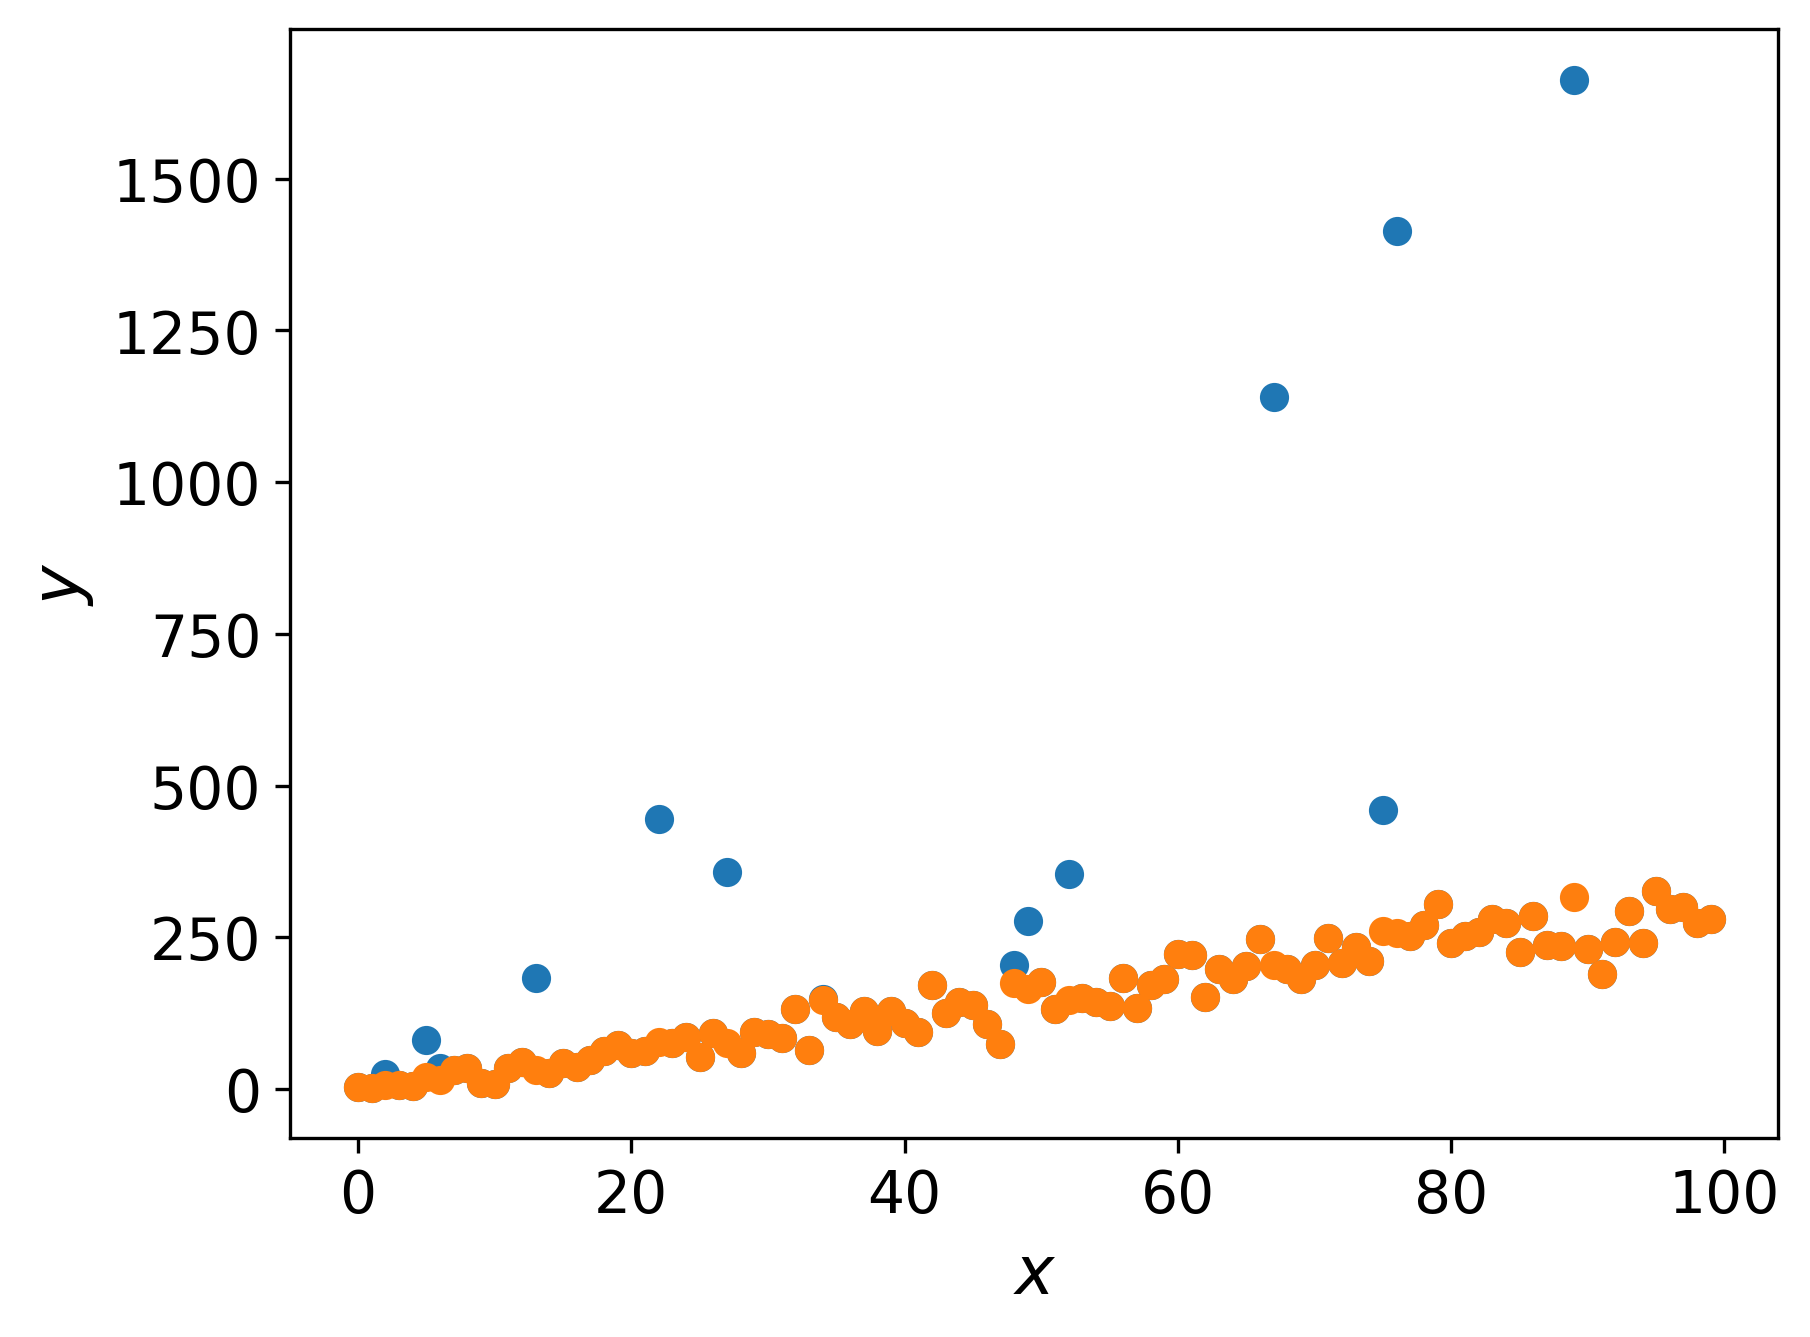

In [5]:
fig1 = plt.figure()
plt.scatter(x,y_wo)
plt.scatter(x,y)
plt.xlabel('$x$')
plt.ylabel('$y$')

We can see the effect for the MSE loss right away:

In [6]:
start_time = time.perf_counter()
model.fit(X,y_wo)
end_time = time.perf_counter()
print('elapsed time = ', end_time-start_time)
slope_opt, intercept_opt = model.coef_, model.intercept_
print(intercept_opt, slope_opt)

elapsed time =  0.0007582000689581037
1.5481188118811815 [3.97842184]


These are the parameters obtained for the normal equation; we can save them to compare them to other methods.

In [7]:
beta_ne = np.array([[intercept_opt],[slope_opt[0]]])

### Let's now implement the simplest form of gradient descent: batch, stochastic, and mini-batch, one by one.

To begin with, we add x0 = 1 to each instance; this is the bias term and it is used in order to write the solution for a linear model in matrix multiplication form.

In [8]:
X = np.c_[np.ones((100, 1)), x]  
print(X.shape) #shape is number of instances x number of parameters
print(X[:10]) # first 10 rows

(100, 2)
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]
 [1. 8.]
 [1. 9.]]


We can calculate the MSE loss associated with the normal equation like this:

In [9]:
loss_ne = np.mean((X.dot(beta_ne) - y_wo.reshape(-1,1))**2)
y_pred = model.predict(x.reshape(-1,1))
MSE = metrics.mean_squared_error(y_wo, y_pred)
print(loss_ne, MSE) # check it's working (slight numerical difference?)

43259.081624722465 43259.081624722465


### Batch Gradient Descent (BGD)

In [10]:
start_time = time.perf_counter()

np.random.seed(10) #same initial conditions for all
beta = np.random.randn(2,1)
print('initial guess for intercept, slope = ', beta[0], beta[1])

eta = 0.0001
n_iterations = 1000 #try changing this number!
N = len(x)
beta_path_bgd = []

for iteration in range(n_iterations):
    gradients = 2/N * X.T.dot(X.dot(beta) - y_wo.reshape(-1,1))
    beta = beta - eta * gradients
    beta_path_bgd.append(beta)

beta_path_bgd = np.array(beta_path_bgd) #save the path

end_time = time.perf_counter()
print('elapsed time = ',end_time-start_time)

beta_bgd = beta #final result
print('final result for intercept, slope = ', beta_bgd[0], beta_bgd[1])

initial guess for intercept, slope =  [1.3315865] [0.71527897]
elapsed time =  0.007119799964129925
final result for intercept, slope =  [1.38909891] [3.98081931]


In [11]:
loss_bgd = np.sum(1/N*(X.dot(beta_bgd) - y_wo.reshape(-1,1))**2)
loss_bgd

np.float64(43259.08804185896)

In [12]:
(loss_ne-loss_bgd)/loss_ne*100 #percent difference with normal equation

np.float64(-1.4834194931614274e-05)

The final value of $\beta$ is very similar, if not identical, to the normal equation solution. It would get closer to it if we increase the number of iterations.

### Stochastic Gradient Descent (SGD)

In [13]:
start_time = time.perf_counter()

np.random.seed(10) #same initial conditions for all
beta = np.random.randn(2,1) 
print('initial guess for intercept, slope = ', beta[0], beta[1])

eta = 0.000005 # lower learning rate
n_iterations = 10000 # more iterations are needed to get in the right ballpark!
beta_path_sgd = []

for epoch in range(n_iterations):
        random_index = np.random.randint(N) # pick one example from the data 
        x_one = X[random_index:random_index+1]
        y_one = y_wo[random_index:random_index+1]
        gradients = 2 * x_one.T.dot(x_one.dot(beta) - y_one)
        beta = beta - eta * gradients
        beta_path_sgd.append(beta)                 

beta_path_sgd = np.array(beta_path_sgd)

end_time = time.perf_counter()
print('elapsed time = ',end_time-start_time)

beta_sgd = beta
print('final result for intercept, slope = ', beta_sgd[0], beta_sgd[1])

initial guess for intercept, slope =  [1.3315865] [0.71527897]
elapsed time =  0.07168809999711812
final result for intercept, slope =  [1.3552955] [4.17721319]


We find similar values for theta as the BG case, but not exactly the same.

In [14]:
loss_sgd = np.sum(1/N*(X.dot(beta_sgd) - y_wo.reshape(-1,1))**2)
loss_sgd

np.float64(43385.08132655123)

In [15]:
(loss_ne-loss_sgd)/loss_sgd*100 #percent difference with normal equation

np.float64(-0.29042172557057777)

### Mini batch Gradient Descent (MGD)

In [16]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html
start_time = time.perf_counter()

np.random.seed(10)
beta = np.random.randn(2,1) 
print('initial guess for intercept, slope = ', beta[0], beta[1])

eta = 0.000005
n_iterations = 1000
beta_path_mgd = []

minibatch_size = 10 # size of the mini batch

for epoch in range(n_iterations):
    shuffled_indices = np.random.permutation(N) #shuffle array 
    X_shuffled = X[shuffled_indices]
    y_shuffled = y_wo.reshape(-1,1)[shuffled_indices]
    xi = X_shuffled[:minibatch_size] #select the first set from the shuffled array; equivalent to selecting a random subset
    yi = y_shuffled[:minibatch_size]
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(beta) - yi)
    beta = beta - eta * gradients
    beta_path_mgd.append(beta)

beta_path_mgd = np.array(beta_path_mgd)

end_time = time.perf_counter()
print('elapsed time = ',end_time-start_time)

beta_mgd = beta 
print('final result for intercept, slope = ', beta_mgd[0], beta_mgd[1])

initial guess for intercept, slope =  [1.3315865] [0.71527897]
elapsed time =  0.011778500047512352
final result for intercept, slope =  [1.38191988] [4.25542902]


In [17]:
loss_mgd = np.sum(1/N*(X.dot(beta_mgd) - y_wo.reshape(-1,1))**2)
loss_mgd

np.float64(43506.50418469318)

In [18]:
(loss_ne-loss_mgd)/loss_ne*100 #percent difference with normal equation

np.float64(-0.5719551841556246)

Same as before.

It's most interesting to actually look at the path taken by GD in the three cases. Increasingly dark colors denote later steps. 

<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_17760\3152593104.py:4: SyntaxWarni

(np.float64(1.3), np.float64(1.4), np.float64(2.5), np.float64(6.5))

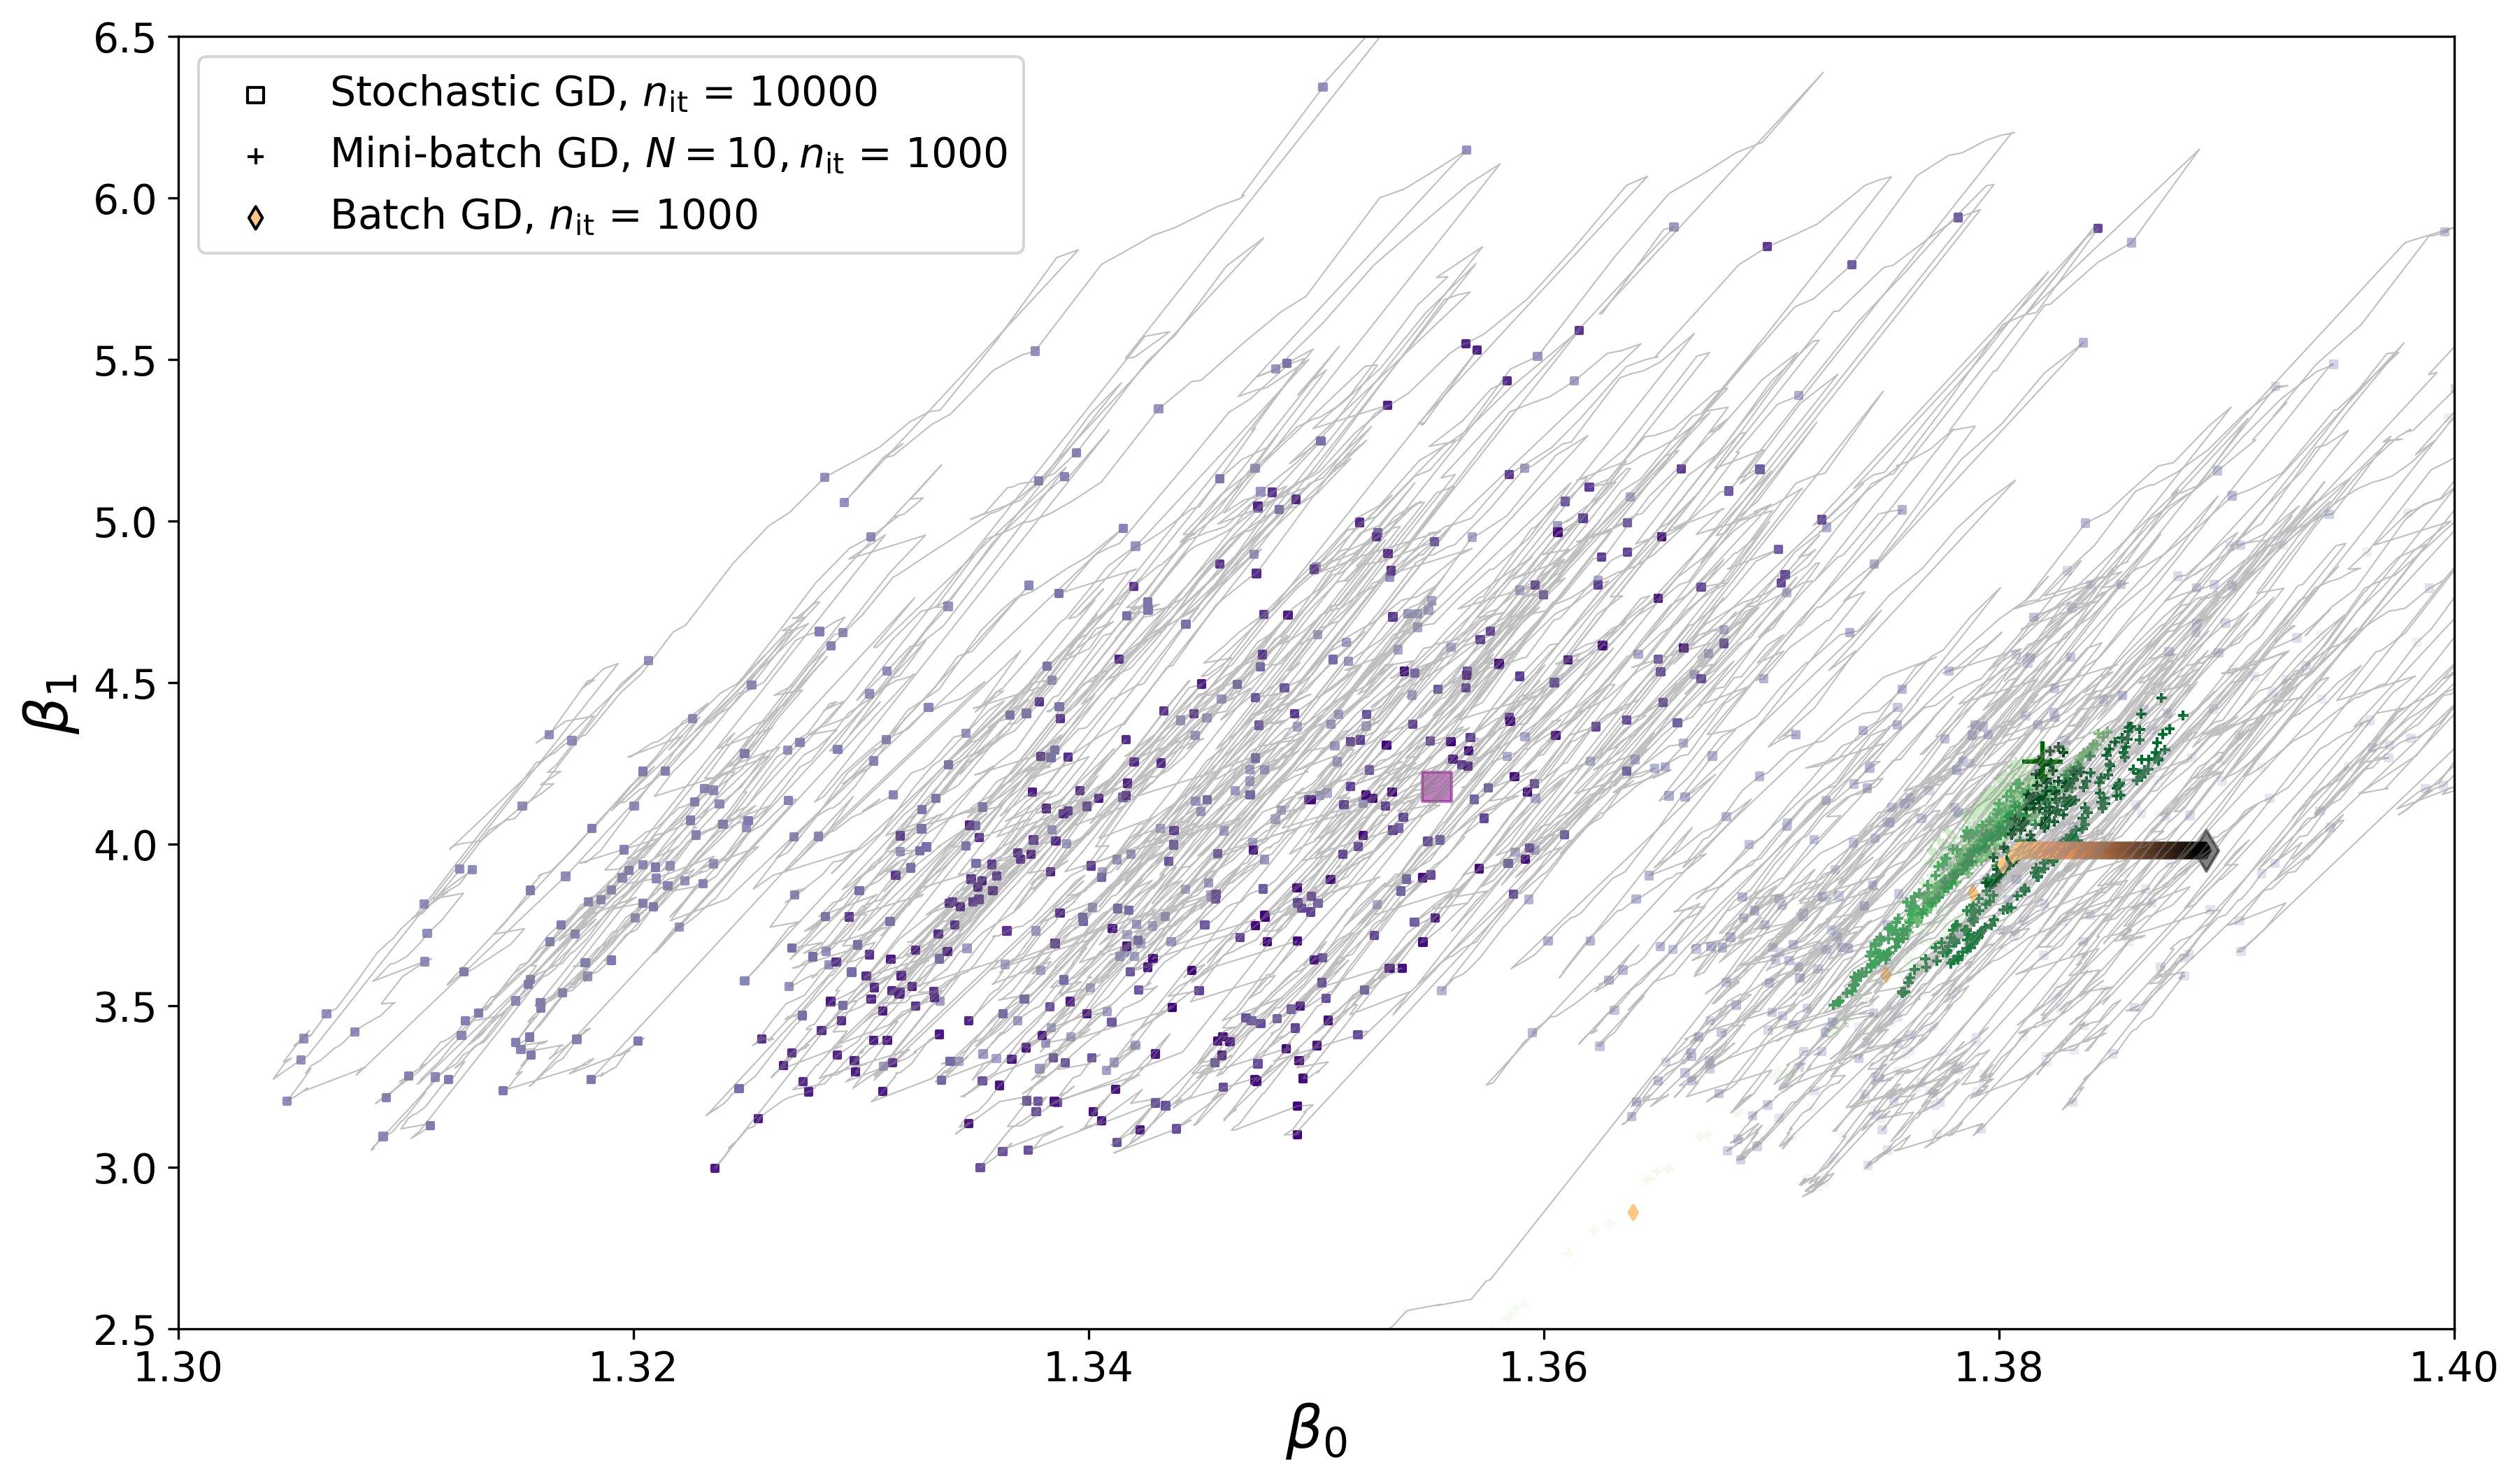

In [19]:
fig2 = plt.figure(figsize=(14,8))

plt.scatter(beta_path_sgd[::10, 0].flatten(), beta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, $n_\mathrm{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.plot(beta_path_sgd[:,0], beta_path_sgd[:,1], '-', c='grey', lw=0.5, alpha=0.5)
plt.scatter(beta_path_mgd[:, 0].flatten(), beta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, $N=10, n_\mathrm{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(beta_path_bgd[:, 0].flatten(), beta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, $n_\mathrm{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(beta_sgd[0],beta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(beta_mgd[0],beta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(beta_bgd[0],beta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)
#plt.text(1.5,3.978,'Normal Equation solution X')

legend = plt.legend(loc="upper left", fontsize=14)

for i in range(3):
    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\beta_0$", fontsize=20)
plt.ylabel(r"$\beta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
#plt.show()


Exercise 1: note what happens for larger learning rates and smaller learning rates. Would an adaptive learning rate be a solution? Qualitatively, how would you choose it?

Exercise 2: Examine the gradients to discover why batch GD stops updating the slope pretty quickly. Would this be a concern in terms of getting stuck on local minima, for loss functions that are not convex?  